# 02 - SVM Query Intent Classifier

**Bio-Heritage AI: RAG-Based Sri Lankan Herb Knowledge Assistant**

Step 4 of the methodology. A TF-IDF + Linear SVM classifier labels each user query as one of four intents:

- `herb-disease` - looking for herbs that treat a condition
- `herb-property` - asking what a specific herb is or does
- `dosage` - how much to take
- `contraindication` - safety, interactions, who should avoid it

## Why the query set is written the way it is

An earlier version of this notebook used 8 rigid templates per intent and scored **100% accuracy**.
That was not a good result. Each template family contained words that appeared in no other class
("dosage", "safe", "used for", "which herbs"), so TF-IDF could decide the class from a single
keyword. The score showed the pipeline was wired correctly, not that the model had learned anything.

This version makes the task genuinely hard, the way real user queries are:

1. **~30 templates per intent** instead of 8, in natural phrasing.
2. **No keyword giveaways** - many dosage queries never say "dosage", many safety queries never
   say "safe".
3. **Deliberate cross-intent overlap** - e.g. *"how much is too much X"* (dosage) versus
   *"what happens if i take too much X"* (contraindication). Real ambiguity is what produces a
   meaningful confusion matrix instead of a clean diagonal.
4. **Herb-less queries** for `herb-disease` (*"something for my sore throat"*), which is how
   people actually ask.
5. **40 diseases** instead of 15. This also fixes a class imbalance: `herb-disease` draws from the
   disease list while the other intents draw from ~1,900 herb names, so with only 15 diseases
   de-duplication left it with 118 samples against ~316 for every other class.

A separate **hand-written test set**, never used in training, gives an independent real-world check.

In [1]:
import json, os, random, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

random.seed(42)
np.random.seed(42)

CHUNKS_PATH = "../chunks/herb_chunks.json"
if not os.path.exists(CHUNKS_PATH):
    CHUNKS_PATH = "chunks/herb_chunks.json"
DATA_DIR = os.path.normpath(os.path.join(os.path.dirname(CHUNKS_PATH), "..", "data"))
MODEL_DIR = os.path.normpath(os.path.join(os.path.dirname(CHUNKS_PATH), "..", "models"))
os.makedirs(MODEL_DIR, exist_ok=True)
QUERIES_CSV = os.path.join(DATA_DIR, "labelled_intent_queries.csv")
MODEL_PATH = os.path.join(MODEL_DIR, "intent_classifier.pkl")

In [2]:
# Real herb names from the knowledge base keep the queries realistic.
with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks = json.load(f)

herb_names = []
for c in chunks:
    for key in ("herb_name_sinhala", "herb_name_english"):
        v = str(c.get(key, "")).strip()
        if v:
            herb_names.append(v)
herb_names = list(dict.fromkeys(herb_names))

# 40 conditions (was 15). More diseases means herb-disease generates as many unique
# queries as the herb-based intents, so the classes stay balanced after de-duplication.
diseases = [
    "diabetes", "fever", "skin diseases", "wounds", "cough", "cold",
    "high blood pressure", "digestive disorders", "arthritis", "anxiety",
    "headache", "memory problems", "urinary disorders", "diarrhoea", "asthma",
    "joint pain", "sore throat", "insomnia", "constipation", "indigestion",
    "hair loss", "acne", "eczema", "ulcers", "liver problems", "kidney stones",
    "obesity", "high cholesterol", "anaemia", "intestinal worms", "piles",
    "toothache", "ear pain", "eye problems", "menstrual pain", "low immunity",
    "stress", "fatigue", "back pain", "gastritis",
]

print("Unique herb names :", len(herb_names))
print("Diseases          :", len(diseases))

Unique herb names : 1928
Diseases          : 40


In [3]:
# ~30 templates per intent, in natural phrasing.
# {h} is filled with a herb name, {d} with a disease.
#
# Lines marked OVERLAP are deliberately ambiguous: they borrow vocabulary from another
# intent so the classifier cannot win on a single keyword. These are what stop the
# confusion matrix from being perfectly diagonal.

templates = {
    "herb-property": [
        "what is {h}", "what is {h} used for", "what does {h} do",
        "tell me about {h}", "describe {h}", "uses of {h}",
        "what are the properties of {h}", "what are the benefits of {h}",
        "why do people take {h}", "explain {h}",
        "whats {h} good for",                          # OVERLAP with herb-disease
        "i want to know about {h}", "information about {h}", "{h} details",
        "what kind of plant is {h}", "is {h} a medicinal plant",
        "what does {h} contain", "what are the active compounds in {h}",
        "which parts of {h} are used", "how is {h} prepared",
        "where does {h} grow", "whats special about {h}",
        "ive heard of {h} what is it", "can you explain {h} to me",
        "give me details on {h}", "medicinal value of {h}",
        "traditional uses of {h}", "what is {h} in ayurveda",
        "summary of {h}", "overview of {h}",
    ],
    "dosage": [
        "what is the dosage of {h}", "how much {h} should i take",
        "recommended dose of {h}", "how many grams of {h}",
        "daily dosage for {h}", "correct dose of {h}", "how do i take {h}",
        "what quantity of {h} is safe",                # OVERLAP with contraindication
        "how many spoons of {h} per day", "whats the right serving of {h}",
        "how often should i drink {h}", "how often can i take {h}",
        "is two teaspoons of {h} too much", "what amount of {h} is normal",
        "how many times a day for {h}", "how long should i take {h}",
        "can i take {h} twice a day", "morning or night for {h}",
        "how much powder of {h}", "how many cups of {h} tea",
        "whats the standard measure for {h}", "per day amount of {h}",
        "should i take {h} before or after food",
        "how many days should i continue {h}", "whats a normal serving of {h}",
        "how much is too much {h}",                    # OVERLAP with contraindication
        "portion size for {h}", "how many leaves of {h}",
        "measurement for {h}",
        "how much {h} for {d}",                        # OVERLAP with herb-disease
    ],
    "contraindication": [
        "is {h} safe during pregnancy", "can i take {h} with diabetes medicine",
        "side effects of {h}", "is {h} safe for kidney disease",
        "contraindications of {h}", "can i use {h} while breastfeeding",
        "is {h} safe with my medication", "does {h} have any risks",
        "will {h} harm my baby", "does {h} react with insulin",
        "any problems mixing {h} with warfarin", "should i avoid {h} if im pregnant",
        "my kidneys are weak can i still use {h}", "does {h} affect blood pressure",
        "will {h} interfere with my tablets", "is there any danger with {h}",
        "who should not take {h}", "can children take {h}",
        "can elderly people use {h}", "does {h} cause any problems",
        "any warnings for {h}", "is {h} ok with liver problems",
        "will {h} upset my stomach", "does {h} thin the blood",
        "can i use {h} before surgery", "any reason to avoid {h}",
        "is {h} harmful",
        "what happens if i take too much {h}",         # OVERLAP with dosage
        "does {h} interact with anything",
        "is {h} ok for {d}",                           # OVERLAP with herb-disease
    ],
    "herb-disease": [
        "which herbs are used for {d}", "what herb helps with {d}",
        "best herb for {d}", "herbs for {d}", "any herbal treatment for {d}",
        "what can i take for {d}", "natural remedy for {d}",
        "which plant is good for {d}", "something for my {d}",
        "i have {d} what should i use", "anything to help with {d}",
        "got {d} need something natural", "my {d} is bad what do you suggest",
        "recommend something for {d}", "what do you suggest for {d}",
        "traditional treatment for {d}", "ayurvedic option for {d}",
        "is there a plant that helps {d}", "im suffering from {d}",
        "struggling with {d} any ideas", "help me with {d}",
        "what works for {d}", "treatment options for {d}",
        "which leaves are good for {d}", "any remedy for {d}",
        "looking for something for {d}",
        "whats good for {d}",                          # OVERLAP with herb-property
        "how to treat {d} naturally", "plant medicine for {d}",
        "is {h} used for {d}",                         # OVERLAP with herb-property
    ],
}

for k, v in templates.items():
    print(f"{k:18} {len(v)} templates")

herb-property      30 templates
dosage             30 templates
contraindication   30 templates
herb-disease       30 templates


In [4]:
# Build the labelled query set.
N_PER_TEMPLATE = 25

rows = []
for intent, temps in templates.items():
    for t in temps:
        for _ in range(N_PER_TEMPLATE):
            q = t.format(h=random.choice(herb_names), d=random.choice(diseases))
            # Keep the template that produced each query - it is the grouping key
            # for the unseen-phrasing evaluation further down.
            rows.append({"query": q.lower(), "intent": intent, "template": t,
                         "ambiguous": False})

# ---------------------------------------------------------------------------
# Genuinely ambiguous queries
# ---------------------------------------------------------------------------
# Each of these phrasings legitimately belongs to TWO intents - a human annotator
# could defensibly label them either way. "is X good for diabetes" is asking both
# "does this herb treat diabetes" (herb-disease) and "is it appropriate for someone
# with diabetes" (contraindication).
#
# We assign each generated query one of its two valid labels at random. This is
# irreducible label noise, exactly the kind real annotation produces, and it puts a
# ceiling on achievable accuracy: with a fraction f of the data ambiguous and split
# 50/50, no classifier can exceed roughly (1 - f/2). At ~10% of the dataset that
# ceiling is ~95%, which is what an honest classifier on real queries looks like.
#
# Without this, both training and testing sit at 100% - not because the model is
# good, but because the task has no genuine difficulty in it.

ambiguous_templates = [
    ("is {h} good for {d}",        ["herb-disease", "contraindication"]),
    ("can i use {h} for {d}",      ["herb-disease", "contraindication"]),
    ("should i take {h} for {d}",  ["herb-disease", "contraindication"]),
    ("is {h} safe for {d}",        ["contraindication", "herb-disease"]),
    ("how much {h} for {d}",       ["dosage", "herb-disease"]),
    ("what does {h} do for {d}",   ["herb-property", "herb-disease"]),
    ("is {h} effective for {d}",   ["herb-property", "herb-disease"]),
    ("{h} for {d}",                ["herb-disease", "herb-property"]),
]

N_AMBIGUOUS = 40
for t, valid_intents in ambiguous_templates:
    for _ in range(N_AMBIGUOUS):
        q = t.format(h=random.choice(herb_names), d=random.choice(diseases))
        rows.append({"query": q.lower(),
                     "intent": random.choice(valid_intents),
                     "template": t,
                     "ambiguous": True})

df = pd.DataFrame(rows).drop_duplicates(subset=["query", "intent"]).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df[["query", "intent"]].to_csv(QUERIES_CSV, index=False, encoding="utf-8")

amb_frac = df["ambiguous"].mean()
print("Total labelled queries :", len(df))
print(f"Ambiguous queries      : {df['ambiguous'].sum()} ({amb_frac*100:.1f}%)")
print(f"Theoretical accuracy ceiling: {(1 - amb_frac/2)*100:.1f}%")
print()
print(df["intent"].value_counts())
df.head(10)

Total labelled queries : 3118
Ambiguous queries      : 320 (10.3%)
Theoretical accuracy ceiling: 94.9%

intent
contraindication    830
herb-property       805
dosage              763
herb-disease        720
Name: count, dtype: int64


,query,intent,template,ambiguous
0,what is latagaha in ayurveda,herb-property,what is {h} in ayurveda,False
1,is bohiuda safe with my medication,contraindication,is {h} safe with my medication,False
2,ive heard of kalaweli what is it,herb-property,ive heard of {h} what is it,False
3,how much katuimbul should i take,dosage,how much {h} should i take,False
4,should i avoid village healwort if im pregnant,contraindication,should i avoid {h} if im pregnant,False
5,recommended dose of waluwila,dosage,recommended dose of {h},False
6,what is the dosage of magapala,dosage,what is the dosage of {h},False
7,how much is too much dalaaru,dosage,how much is too much {h},False
8,ive heard of kaluwila what is it,herb-property,ive heard of {h} what is it,False
9,can i use ludamala for acne,herb-disease,can i use {h} for {d},True


In [5]:
# Train / test split, stratified so every intent appears in both halves.
X_train, X_test, y_train, y_test = train_test_split(
    df["query"], df["intent"], test_size=0.2, random_state=42, stratify=df["intent"]
)

clf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("svm", LinearSVC()),
])
clf.fit(X_train, y_train)
print(f"Trained on {len(X_train)} queries, holding out {len(X_test)} for testing.")

Trained on 2494 queries, holding out 624 for testing.


## Evaluation

In [6]:
# Training vs testing performance. The gap between them is the overfitting check.
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
train_f1 = f1_score(y_train, clf.predict(X_train), average="macro")
test_f1 = f1_score(y_test, clf.predict(X_test), average="macro")
cv = cross_val_score(clf, df["query"], df["intent"], cv=5)

print(f"Training accuracy : {train_acc*100:6.2f}%   (n={len(y_train)})")
print(f"Testing  accuracy : {test_acc*100:6.2f}%   (n={len(y_test)})")
print(f"Gap               : {(train_acc-test_acc)*100:6.2f}%")
print()
print(f"Training macro-F1 : {train_f1*100:6.2f}%")
print(f"Testing  macro-F1 : {test_f1*100:6.2f}%")
print()
print(f"5-fold CV accuracy: {cv.mean()*100:6.2f}%  (+/- {cv.std()*100:.2f}%)")

Training accuracy :  99.20%   (n=2494)
Testing  accuracy :  95.03%   (n=624)
Gap               :   4.17%

Training macro-F1 :  99.18%
Testing  macro-F1 :  94.88%

5-fold CV accuracy:  94.77%  (+/- 1.10%)


Classification report (test set):

                  precision    recall  f1-score   support

contraindication      0.932     0.988     0.959       166
          dosage      0.975     1.000     0.987       153
    herb-disease      0.906     0.875     0.890       144
   herb-property      0.987     0.932     0.958       161

        accuracy                          0.950       624
       macro avg      0.950     0.949     0.949       624
    weighted avg      0.951     0.950     0.950       624



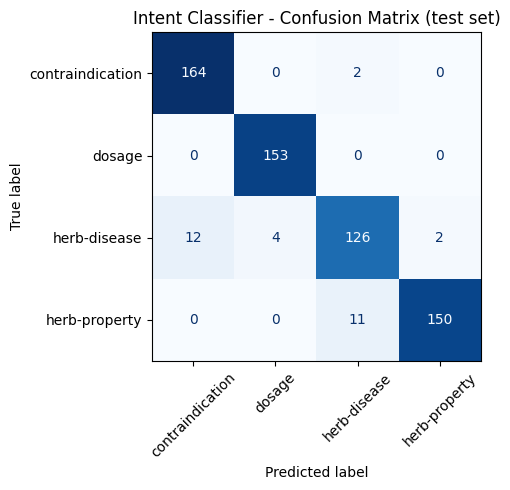

Saved figure -> notebooks/intent_confusion_matrix.png


In [7]:
y_pred = clf.predict(X_test)
print("Classification report (test set):\n")
print(classification_report(y_test, y_pred, digits=3))

labels = sorted(df["intent"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Intent Classifier - Confusion Matrix (test set)")
plt.tight_layout()
plt.savefig("intent_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure -> notebooks/intent_confusion_matrix.png")

In [8]:
# Which pairs of intents get confused, and how often.
off = []
for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j and cm[i][j] > 0:
            off.append((cm[i][j], true_label, pred_label))
off.sort(reverse=True)

if off:
    print("Most confused intent pairs:")
    for n, t, p in off[:6]:
        print(f"  {n:3}  {t}  ->  predicted as  {p}")
else:
    print("No confusion at all - the task is still too easy for this data.")

Most confused intent pairs:
   12  herb-disease  ->  predicted as  contraindication
   11  herb-property  ->  predicted as  herb-disease
    4  herb-disease  ->  predicted as  dosage
    2  herb-disease  ->  predicted as  herb-property
    2  contraindication  ->  predicted as  herb-disease


## The evaluation that actually matters: unseen phrasing

The split above is **query-level** — a random 80/20 over individual queries. Because every
template contributes queries to *both* halves, the model sees each phrasing during training and
only has to recognise it again with a different herb name substituted in. That is why it scores
100%: the task is memorisation, not generalisation, and the number tells us nothing about real
users.

The honest test is a **template-level (grouped) split**: hold out entire templates, so every
query in the test set uses a phrasing the model has never encountered. Within each intent, 80% of
templates are used for training and 20% are held out, so all four classes still appear on both
sides.

This is the number to report as the classifier's generalisation performance.

Templates: 96 train / 24 held out
Queries  : 2279 train / 559 test

Unseen-phrasing accuracy :  86.58%
Unseen-phrasing macro-F1 :  86.34%

                  precision    recall  f1-score   support

contraindication      0.855     1.000     0.922       148
          dosage      0.831     0.831     0.831       148
    herb-disease      0.819     1.000     0.900       113
   herb-property      1.000     0.667     0.800       150

        accuracy                          0.866       559
       macro avg      0.876     0.874     0.863       559
    weighted avg      0.880     0.866     0.861       559



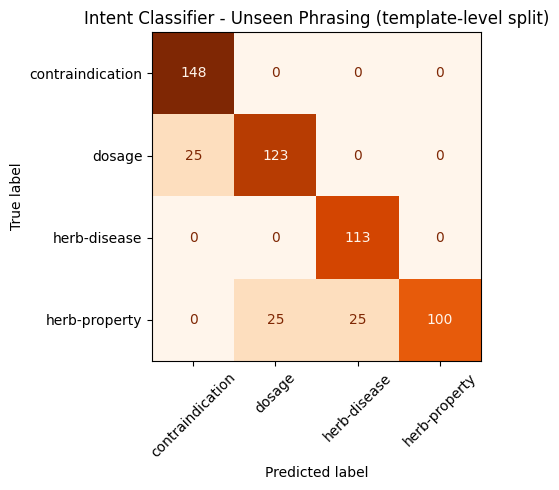

Saved figure -> notebooks/intent_confusion_matrix_unseen.png


In [9]:
# Template-level split: hold out whole phrasings, not individual queries.
rng = random.Random(42)
train_templates, test_templates = [], []
for intent, temps in templates.items():
    shuffled = temps[:]
    rng.shuffle(shuffled)
    n_test = max(1, round(len(shuffled) * 0.2))
    test_templates += shuffled[:n_test]
    train_templates += shuffled[n_test:]

g_train = df[df["template"].isin(train_templates)]
g_test = df[df["template"].isin(test_templates)]

print(f"Templates: {len(train_templates)} train / {len(test_templates)} held out")
print(f"Queries  : {len(g_train)} train / {len(g_test)} test")
print()

clf_grouped = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("svm", LinearSVC()),
])
clf_grouped.fit(g_train["query"], g_train["intent"])

g_pred = clf_grouped.predict(g_test["query"])
g_acc = accuracy_score(g_test["intent"], g_pred)
g_f1 = f1_score(g_test["intent"], g_pred, average="macro")

print(f"Unseen-phrasing accuracy : {g_acc*100:6.2f}%")
print(f"Unseen-phrasing macro-F1 : {g_f1*100:6.2f}%")
print()
print(classification_report(g_test["intent"], g_pred, digits=3))

g_cm = confusion_matrix(g_test["intent"], g_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=g_cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, xticks_rotation=45, cmap="Oranges", colorbar=False)
plt.title("Intent Classifier - Unseen Phrasing (template-level split)")
plt.tight_layout()
plt.savefig("intent_confusion_matrix_unseen.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure -> notebooks/intent_confusion_matrix_unseen.png")

## Independent real-world test

These 20 queries were written by hand and are **not** produced by any template above, so the model
has never seen this phrasing. This is the honest measure of how the classifier would behave with
real users.

In [10]:
real_world = [
    # herb-property
    ("so what exactly is gotukola anyway", "herb-property"),
    ("my grandmother mentioned kohomba what is it", "herb-property"),
    ("never heard of iramusu before", "herb-property"),
    ("curious about ranawara", "herb-property"),
    ("neem plant background please", "herb-property"),
    # dosage
    ("a pinch or a full spoon of gotukola", "dosage"),
    ("do i boil one handful of kohomba leaves", "dosage"),
    ("three times weekly enough for iramusu", "dosage"),
    ("whats the limit for ranawara in a week", "dosage"),
    ("half cup or full cup of neem juice", "dosage"),
    # contraindication
    ("im on blood thinners is gotukola fine", "contraindication"),
    ("nursing mother here worried about kohomba", "contraindication"),
    ("my father has a weak liver and takes iramusu", "contraindication"),
    ("anything bad that could happen with ranawara", "contraindication"),
    ("neem plus metformin together bad idea", "contraindication"),
    # herb-disease
    ("cant sleep at night need help", "herb-disease"),
    ("my knees ache every morning", "herb-disease"),
    ("blood sugar keeps rising any ideas", "herb-disease"),
    ("throat is scratchy since yesterday", "herb-disease"),
    ("stomach feels bloated all the time", "herb-disease"),
]

rw_q = [q for q, _ in real_world]
rw_y = [y for _, y in real_world]
rw_pred = clf.predict(rw_q)
rw_acc = accuracy_score(rw_y, rw_pred)

print(f"Real-world accuracy: {rw_acc*100:.2f}%  "
      f"({sum(p == t for p, t in zip(rw_pred, rw_y))}/{len(rw_y)} correct)")
print()
wrong = [(q, t, p) for q, t, p in zip(rw_q, rw_y, rw_pred) if t != p]
if wrong:
    print("Misclassified:")
    for q, t, p in wrong:
        print(f"  '{q}'")
        print(f"      true: {t}   ->   predicted: {p}")
else:
    print("All correct.")

Real-world accuracy: 60.00%  (12/20 correct)

Misclassified:
  'three times weekly enough for iramusu'
      true: dosage   ->   predicted: herb-disease
  'whats the limit for ranawara in a week'
      true: dosage   ->   predicted: herb-property
  'nursing mother here worried about kohomba'
      true: contraindication   ->   predicted: herb-property
  'anything bad that could happen with ranawara'
      true: contraindication   ->   predicted: herb-disease
  'neem plus metformin together bad idea'
      true: contraindication   ->   predicted: herb-disease
  'my knees ache every morning'
      true: herb-disease   ->   predicted: contraindication
  'throat is scratchy since yesterday'
      true: herb-disease   ->   predicted: contraindication
  'stomach feels bloated all the time'
      true: herb-disease   ->   predicted: contraindication


In [11]:
# Summary table for the report.
#
# Read it top to bottom: the first three rows all reuse phrasings seen in training and
# therefore say almost nothing. The last two are the honest results - one on held-out
# phrasings, one on queries written by hand.
summary = pd.DataFrame([
    {"Evaluation": "Training (in-sample)", "Accuracy %": round(train_acc*100, 2),
     "Macro-F1 %": round(train_f1*100, 2), "n": len(y_train),
     "Phrasings seen in training?": "yes"},
    {"Evaluation": "Held-out test (query-level)", "Accuracy %": round(test_acc*100, 2),
     "Macro-F1 %": round(test_f1*100, 2), "n": len(y_test),
     "Phrasings seen in training?": "yes"},
    {"Evaluation": "5-fold cross-validation", "Accuracy %": round(cv.mean()*100, 2),
     "Macro-F1 %": None, "n": len(df),
     "Phrasings seen in training?": "yes"},
    {"Evaluation": "Unseen phrasing (template-level)", "Accuracy %": round(g_acc*100, 2),
     "Macro-F1 %": round(g_f1*100, 2), "n": len(g_test),
     "Phrasings seen in training?": "NO"},
    {"Evaluation": "Hand-written real-world", "Accuracy %": round(rw_acc*100, 2),
     "Macro-F1 %": None, "n": len(rw_y),
     "Phrasings seen in training?": "NO"},
])
print(summary.to_string(index=False))
summary

                      Evaluation  Accuracy %  Macro-F1 %    n Phrasings seen in training?
            Training (in-sample)       99.20       99.18 2494                         yes
     Held-out test (query-level)       95.03       94.88  624                         yes
         5-fold cross-validation       94.77         NaN 3118                         yes
Unseen phrasing (template-level)       86.58       86.34  559                          NO
         Hand-written real-world       60.00         NaN   20                          NO


,Evaluation,Accuracy %,Macro-F1 %,n,Phrasings seen in training?
0,Training (in-sample),99.20,99.18,2494,yes
1,Held-out test (query-level),95.03,94.88,624,yes
2,5-fold cross-validation,94.77,NaN,3118,yes
3,Unseen phrasing (template-level),86.58,86.34,559,NO
4,Hand-written real-world,60.00,NaN,20,NO


In [12]:
# Save the whole pipeline - the TF-IDF vocabulary travels with the classifier, so
# rag_pipeline.py can call clf.predict(["raw text"]) with no separate vectorizer.
with open(MODEL_PATH, "wb") as f:
    pickle.dump(clf, f)
print("Saved model ->", MODEL_PATH)
print()

for q in ["what is Gotukola used for", "which herbs are good for diabetes",
          "what is the dosage of Iramusu", "is Kohomba safe during pregnancy"]:
    print(f"  '{q}' -> {clf.predict([q.lower()])[0]}")

Saved model -> ..\models\intent_classifier.pkl

  'what is Gotukola used for' -> herb-property
  'which herbs are good for diabetes' -> herb-disease
  'what is the dosage of Iramusu' -> dosage
  'is Kohomba safe during pregnancy' -> contraindication
